# Лабораторная работа №1: регрессия
## 1. Знакомство с данными

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
RANDOM_STATE = 42

In [2]:
URL_RED = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
URL_WHITE = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df = pd.read_csv(URL_RED, sep=";")
print("Размер:", df.shape)
df.head()

Размер: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Таблица включает информацию о 1599 красных винах. Для каждого вина известны 11 физико-химических характеристик: нелетучие и летучие кислоты, лимонная кислота, сахар, соль, свободный диоксид серы, общий диоксид серы, плотность, pH, сульфаты, крепость алкоголя. Целевая переменная — quality, оценка качества дегустаторами по шкале от 0 до 10. Задача — по признакам предсказать quality, это задача регрессии.

In [3]:
df.info()
print("Пропуски по столбцам:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Пропуски по столбцам:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides  

### Вывод по типам данных и пропускам

Таблица не содержит пропусков: во всех 12 столбцах по 1599 непустых значений. Значит, заполнять пропуски или удалять строки не требуется.

Все 11 физико-химических признаков хранятся в формате `float64`, а целевая переменная `quality` — в формате `int64`. Категориальных признаков нет, поэтому кодирование не нужно: данные можно сразу использовать для обучения моделей.

Оценки `quality` дискретные (целые числа), но по условию задачи решается регрессия, поэтому модель будет предсказывать непрерывное значение.

In [4]:
n_dup = df.duplicated().sum()
print("Строк дубликатов:", n_dup)
print("Доля от всех строк:", round(n_dup / len(df), 3))

Строк дубликатов: 240
Доля от всех строк: 0.15


### Вывод по дубликатам

В датасете 240 строк (15% данных) полностью повторяют уже встречавшиеся строки. Возможно, это разные вина с одинаковыми результатами измерений, но для модели они неотличимы.

Если не удалить дубликаты, одно и то же вино может оказаться и в train, и в test. Тогда модель будет проверяться на данных, которые она уже видела, и ошибка выйдет меньше, чем на самом деле. Поэтому дубликаты удаляю до разбиения на выборки.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("Размер после удаления дубликатов:", df.shape)

Размер после удаления дубликатов: (1359, 12)


После удаления дубликатов осталось 1359 вин.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


### Вывод по описательной статистике

Признаки измерены в разных единицах и сильно различаются по масштабу: std у density около 0,0019, а у total sulfur dioxide около 33,41. Поэтому для линейной регрессии признаки нужно стандартизировать, иначе её коэффициенты нельзя сравнивать.

У нескольких признаков есть выбросы — максимум сильно больше 75%-квантиля: chlorides (примерно в 6,7 раз), residual sugar (примерно в 6 раз), total sulfur dioxide (примерно в 4,6 раза), free sulfur dioxide (примерно в 3,4 раза). Выбросы сильнее всего влияют на линейную регрессию, потому что она минимизирует квадраты ошибок и далёкие точки сильно на неё влияют. Удалять их не стоит, так как это могут быть настоящие вина, которые могут встретиться в тестовых данных.

Целевая переменная quality: среднее 5,62, std 0,82. Значит, baseline (предсказание среднего) даст RMSE около 0,82, это хуже порога 0,70.

Количество вин с каждой оценкой:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

Доли:
quality
3    0.007
4    0.039
5    0.425
6    0.394
7    0.123
8    0.013
Name: count, dtype: float64


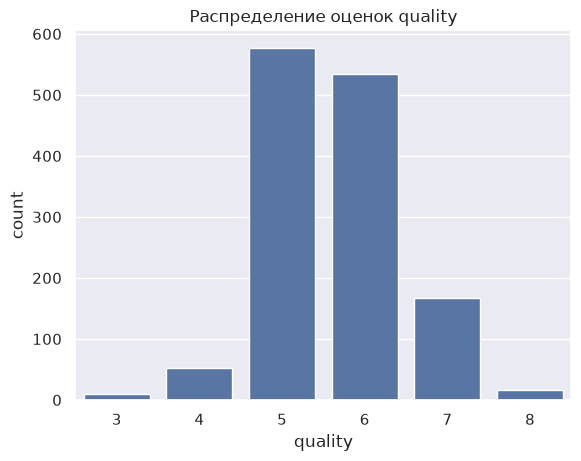

Среднее quality: 5.623
Стандартное отклонение quality: 0.824


In [7]:
counts = df["quality"].value_counts().sort_index()
print("Количество вин с каждой оценкой:")
print(counts)
print()
print("Доли:")
print((counts / len(df)).round(3))

sns.countplot(x="quality", data=df)
plt.title("Распределение оценок quality")
plt.show()

print("Среднее quality:", round(df["quality"].mean(), 3))
print("Стандартное отклонение quality:", round(df["quality"].std(), 3))

### Вывод по целевой переменной

Оценки распределены неравномерно: 5 и 6 вместе составляют около 82% данных, а оценки 3 и 8 — около 2%. Оценок 0, 1, 2, 9, 10 в данных нет совсем.

Из-за этого модель будет хорошо предсказывать вина с оценками 5 и 6, а для редких оценок будет ошибаться сильнее: она будет сдвигать предсказания к среднему. На таких винах модель будет ошибаться сильно, а в RMSE ошибки возводятся в квадрат, поэтому большие ошибки сильно увеличат итоговую метрику.

## 2. Связь признаков с quality

volatile acidity       -0.395
density                -0.184
total sulfur dioxide   -0.178
chlorides              -0.131
pH                     -0.055
free sulfur dioxide    -0.050
residual sugar          0.014
fixed acidity           0.119
citric acid             0.228
sulphates               0.249
alcohol                 0.480
Name: quality, dtype: float64


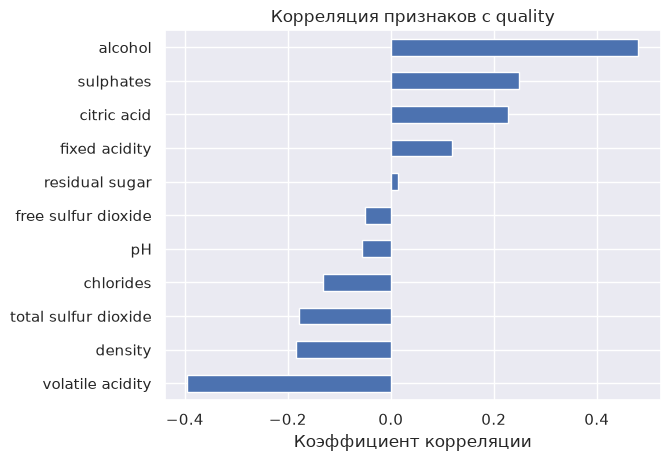

In [8]:
corr_with_quality = df.corr()["quality"].drop("quality").sort_values()
print(corr_with_quality.round(3))

corr_with_quality.plot(kind="barh")
plt.title("Корреляция признаков с quality")
plt.xlabel("Коэффициент корреляции")
plt.show()

### Выводы по корреляции данных с quality

Параметр alcohol имеет самую высокую корреляцию с качеством, соответственно вина с высоким показателем данной переменной в среднем получают оценку выше.

Параметр volatile acidity имеет самую сильную отрицательную корреляцию, следовательно вина с низким показателем данного параметра в среднем получают более высокую оценку.

Корреляция с параметром residual sugar близка к 0, то есть линейной связи нет.

Даже у лучшего признака корреляция около 0.5, поэтому по одному признаку оценку не предсказать - модели нужно учитывать признаки вместе.

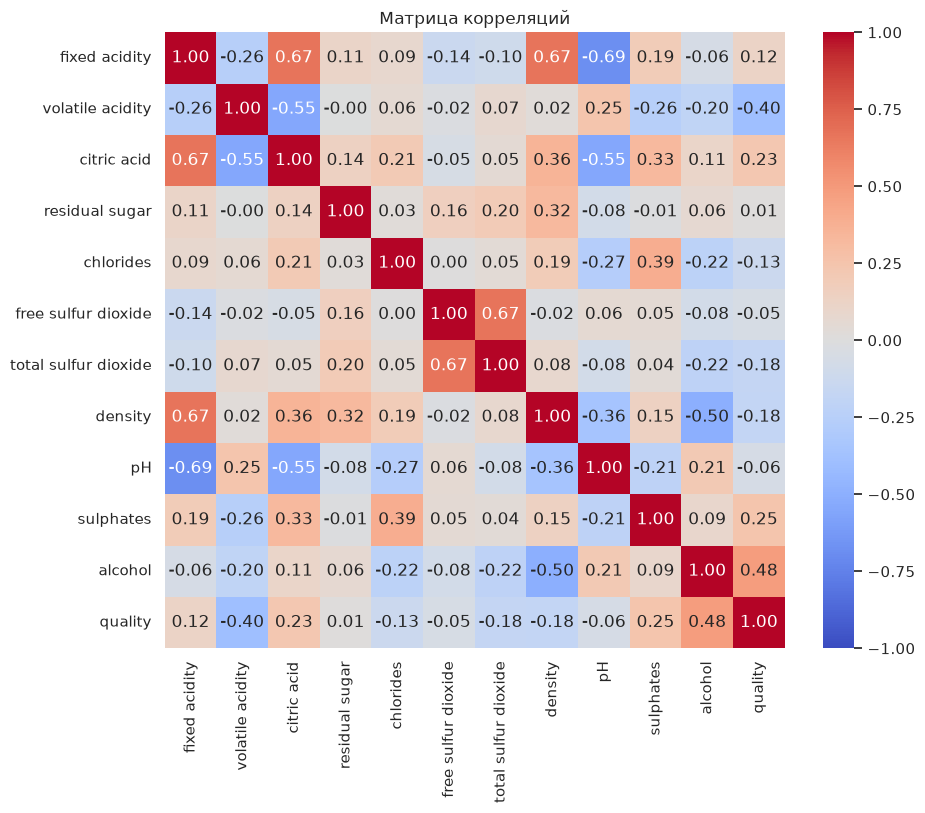

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Матрица корреляций")
plt.show()

### Выводы по корреляции признаков между собой

Самая высокая корреляция (около 0,67) замечена между fixed acidity и citric acid, fixed acidity и density, а также free sulfur dioxide и total sulfur dioxide. Для SO₂ и для кислот это логично: свободный SO₂ — часть общего, а лимонная кислота входит в нелетучие кислоты. Самая сильная отрицательная корреляция у pH и fixed acidity (−0,69), что тоже логично: чем больше кислот, тем ниже pH.

Сильно связанные признаки несут похожую информацию. Из-за этого коэффициенты линейной регрессии у них могут быть неустойчивыми, а важность в деревьях будет делиться между ними.Нужно это учесть в feature importance.

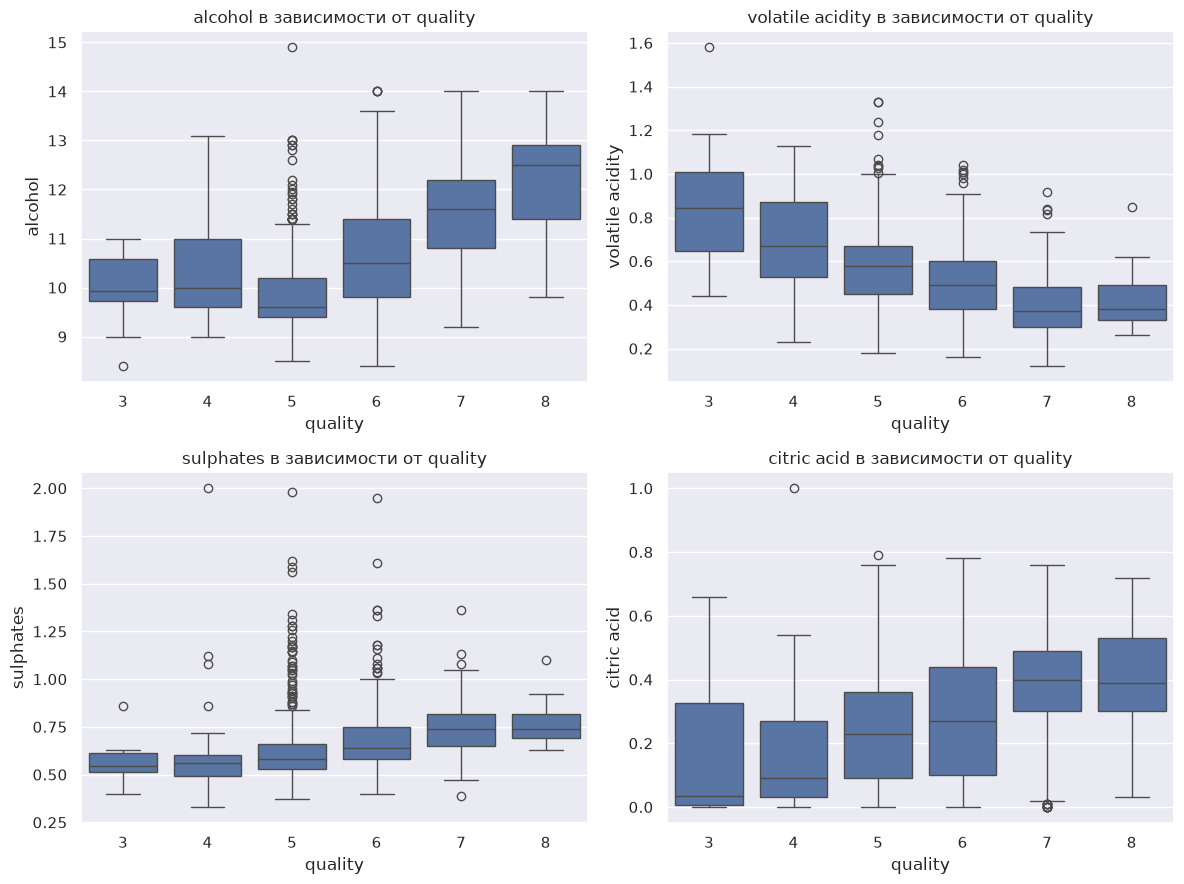

In [10]:
top_features = corr_with_quality.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x="quality", y=feature, data=df, ax=axes[i])
    axes[i].set_title(f"{feature} в зависимости от quality")

plt.tight_layout()
plt.show()

### Выводы по boxplot

**alcohol:** С ростом оценки алкоголь в целом растёт, но не равномерно: у оценок 3–5 медиана почти одинаковая, а с 5 до 8 медиана заметно растёт. То есть алкоголь хорошо отличает хорошие вина (7–8) от средних, но почти не помогает различать плохие и средние.

**volatile acidity:** Медиана плавно падает с 3 по 7 оценки, а у 7 и 8 почти одинаковая. Это самая равномерная зависимость из четырёх.

**sulphates:** Медиана растёт в основном от 5 к 7, у оценок 3–4 и 7–8 почти не меняется. У оценок 5 и 6 много выбросов вверх, до 2,0.

**citric acid:** Медиана растёт от почти 0 у оценки 3 до 0,4 у оценок 7–8. Разброс у плохих вин очень большой: у оценки 3 ящик тянется от 0 до 0,33.

Ящики соседних оценок, особенно 5 и 6, сильно перекрываются на всех четырёх графиках.По одному признаку вина с соседними оценками не различить, что согласуется с умеренными корреляциями. Модели придётся учитывать признаки вместе, и нелинейные модели здесь могут помочь: например, алкоголь работает по-разному для плохих и хороших вин.

Для оценок 3 и 8 данных мало (около 10 и 17 вин), поэтому их ящики ненадёжны, и на таких винах модель, скорее всего, будет ошибаться сильнее.

## 3. Разбиение на train и test

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("train:", X_train.shape)
print("test:", X_test.shape)

train: (1087, 11)
test: (272, 11)


In [12]:
dist = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).round(3)

dist

,train,test
quality,,
3,0.007,0.007
4,0.039,0.040
5,0.424,0.426
6,0.394,0.393
7,0.123,0.121
8,0.013,0.011


### Вывод по разбиению

Возьмём 80% данных на обучение и 20% на тест. Это нужно, чтобы модели хватило данных для обучения, а тест был достаточно большим для честной оценки.

random_state фиксирует, как перемешиваются данные перед разбиением, поэтому при каждом запуске разбиение одинаковое и результаты можно повторить.

stratify=y делает доли каждой оценки в train и test одинаковыми, что видно в таблице выше. Без этого редкие оценки 3 и 8 могли бы почти все попасть в одну часть.

Тестовую выборку используем только один раз в конце, чтобы не подогнать выбор модели под тест, иначе оценка качества будет завышенной.

### Baseline

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Baseline: всегда предсказываем среднее quality по train
baseline_value = y_train.mean()
y_pred_baseline = np.full(len(y_test), baseline_value)

rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("Константа (среднее по train):", round(baseline_value, 3))
print("RMSE:", round(rmse_baseline, 3))
print("MAE:", round(mae_baseline, 3))

Константа (среднее по train): 5.626
RMSE: 0.819
MAE: 0.692


### Вывод по baseline

В качестве baseline всем винам предсказываем одно число — среднее quality по train (5,626). Среднее выбрано, потому что для RMSE сумма квадратов ошибок будет минимальной. Считаем его по train, потому что данные из test модели пока недоступны.

MAE показывает средний модуль ошибок. У baseline MAE = 0.692, то есть в среднем он ошибается на 0.692 балла.

RMSE показывает квадратный корень из среднего квадратов ошибок. Это позволяет сильнее штрафовать большие ошибки. У baseline RMSE = 0,819, и он заметно больше MAE, значит, есть крупные промахи — на редких оценках. RMSE больше порога 0,70, поэтому одного среднего недостаточно: модели нужно использовать признаки, чтобы снизить ошибку.